# Calibración de la tracción — TPF Robótica IA

**Robot autónomo de aproximación / evasión basado en visión** · Raspberry Pi 5 (percepción) + ESP32 (control de bajo nivel) + driver L298N + 2 × motorreductores GM25-370.

Este cuaderno reconstruye, a partir de los datos crudos medidos en banco, la **calibración de las dos ruedas motrices**: qué problema apareció, cómo se lo midió, qué cuentas se hicieron, qué quedó cargado en el firmware y qué zonas del rango de duty resultan inutilizables.

| | |
|---|---|
| **Mediciones** | 2026-07-24 (bring-up) y 2026-08-27 (calibración) |
| **Instrumento** | el propio firmware: modo de calibración `K` / `V` / `C`, que trabaja sobre *duty crudo* |
| **Fuentes** | `HARDWARE.md` §0.4 y §0.5 · `PLAN.md` §13 (bitácora, Día 5) · `firmware/esp32_control/src/main.cpp` |
| **Cómo leerlo** | *Cell → Run All*. No necesita hardware conectado: los datos medidos están embebidos. |

---

### Índice

1. El problema: por qué hay que calibrar, y qué es la zona muerta
2. El método de medición
3. El ajuste lineal y lo que reveló
4. Dos calibraciones que fallaron
5. La calibración final: dos ruedas, dos rectas, una sola velocidad
6. Rango útil y presupuesto del lazo de visión
7. Consecuencias para la ley de control
8. Lección metodológica

In [1]:
# --- Entorno, paleta y estilo de figuras ----------------------------------
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIGURAS = Path.cwd() / "figuras"
FIGURAS.mkdir(exist_ok=True)

# Dos series categóricas (una por rueda) + tinta e infraestructura del gráfico.
C_IZQ, C_DER = "#2a78d6", "#eb6834"   # slots categóricos 1 y 2
C_CRIT       = "#d03b3b"              # estado crítico: duty de calado
SURFACE      = "#fcfcfb"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS   = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 200,
    "savefig.bbox": "tight",
})

def marco(ax, titulo=None, subtitulo=None):
    # Cromo común de todas las figuras: grilla discreta, sin marco derecho ni superior.
    ax.grid(True)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    if titulo:
        ax.set_title(titulo, loc="left", fontsize=12, fontweight="bold",
                     pad=26 if subtitulo else 10)
    if subtitulo:
        ax.text(0, 1.02, subtitulo, transform=ax.transAxes,
                fontsize=9.5, color=INK2, va="bottom")
    return ax

def guardar(fig, nombre):
    fig.savefig(FIGURAS / nombre)
    print(f"figura guardada en figuras/{nombre}")

def coma(x, dec=2):
    # separador decimal en castellano, para las anotaciones de los gráficos
    return f"{x:.{dec}f}".replace(".", ",")

print("Entorno listo.")

Entorno listo.


## 1. El problema: por qué hay que calibrar, y qué es la zona muerta

El robot es un **diferencial de dos ruedas sin encoders**: la velocidad de cada rueda se comanda en **lazo abierto**. La Raspberry Pi baja al ESP32 una intención de movimiento `M,<v_lin>,<v_ang>`, el ESP32 la mezcla en un comando normalizado por rueda `u ∈ (0, 1]` y lo traduce a un **duty de PWM** de 10 bits (0–1023) a 1 kHz.

Para que eso funcione hacen falta dos cosas:

1. **Mismo `u` → misma velocidad real en las dos ruedas.** Si no, el robot no va derecho, y sin encoders nada lo corrige.
2. **El rango de velocidades tiene que entrar en el presupuesto del lazo de visión** (inferencia a ~5 FPS): si el robot es demasiado rápido, avanza a ciegas entre frame y frame.

### La zona muerta

Un motor de corriente continua con reductor **no responde linealmente al duty desde cero**. Por debajo de cierto duty simplemente no gira. Se suman dos causas:

- **Fricción estática** del conjunto motor + caja reductora: hace falta un par mínimo para despegar.
- **Caída de tensión del driver L298**, medida en este proyecto en **2,5 V** (el datasheet hacía esperar 1,4 V). De los 12 V de la batería al motor le llegan ~9,5 V a duty pleno, y esa caída se come justamente el tramo bajo del rango.

Hay que distinguir **dos** zonas muertas, y confundirlas fue uno de los errores de este proyecto:

| | Qué es | Cómo se mide |
|---|---|---|
| **Estática** | duty mínimo para **arrancar** desde parado | subir el duty desde 0 hasta que la rueda se despegue |
| **Cinética (calado)** | duty mínimo para **seguir** girando una vez en movimiento | arrancar la rueda y **bajar** el duty hasta que se plante (rampa `K`) |

La estática es siempre la más alta. La que le importa a la ley de control es la **cinética**; la estática se cubre aparte, con un **pulso de arranque** (*breakaway*) de 80 ms.

### La compensación

El firmware mapea el comando normalizado al tramo útil de cada rueda:

$$\text{duty}_i(u) \;=\; \text{PWM\_MIN}_i + \big(\text{PWM\_TOP}_i - \text{PWM\_MIN}_i\big)\cdot u$$

Toda la calibración consiste en encontrar esos cuatro números — **uno por rueda** — de manera que las dos ruedas describan **la misma recta de velocidad**.

### El síntoma que disparó todo

En el bring-up (2026-07-24) ya se había visto que las ruedas no arrancan al mismo PWM: la derecha a 32 y la izquierda a 64 en escala de 8 bits, una asimetría de 2:1. Se intercambiaron los motores entre canales del L298 y **el umbral alto viajó con el motor**: no es el driver, ni el firmware, ni el cableado. Es el motor.

Con la compensación de piso ya activa, cargada con esos umbrales **estáticos**, al comandar el **20 %** apareció el síntoma que motivó toda la medición: *la rueda derecha giraba bastante más lento que la izquierda*.

In [2]:
# --- Constantes físicas y del firmware ------------------------------------
DIAM_RUEDA_M = 0.060                    # medido (HARDWARE.md §0.2)
CIRCUNF_M    = np.pi * DIAM_RUEDA_M     # avance por vuelta del eje de salida
VENTANA_S    = 10.0                     # ventana de conteo del comando V
PWM_MAX      = 1023                     # 10 bits (HARDWARE.md §0.4, palanca A)
V_BORNES_100 = 9.5                      # V en bornes del motor a duty pleno (12 V − 2,5 V del L298)
FPS_VISION   = 5.0                      # presupuesto del lazo de visión (PLAN.md §10)

def vueltas_a_ms(vueltas_por_ventana):
    # vueltas contadas en la ventana de 10 s -> m/s en la periferia de la rueda
    return np.asarray(vueltas_por_ventana, float) * CIRCUNF_M / VENTANA_S

def ms_a_vueltas(v_ms):
    return np.asarray(v_ms, float) * VENTANA_S / CIRCUNF_M

def duty_a_volt(duty):
    # Tensión media aproximada en bornes del motor. Es una aproximación: la caída
    # del L298 crece con la corriente, así que a duty bajo el valor real es algo mayor.
    return V_BORNES_100 * np.asarray(duty, float) / PWM_MAX

print(f"Circunferencia de rueda : {CIRCUNF_M*100:.2f} cm por vuelta")
print(f"1 vuelta / 10 s         : {vueltas_a_ms(1)*100:.3f} cm/s")
print(f"1 cuenta de duty        : {duty_a_volt(1)*1000:.1f} mV de tensión media")

Circunferencia de rueda : 18.85 cm por vuelta
1 vuelta / 10 s         : 1.885 cm/s
1 cuenta de duty        : 9.3 mV de tensión media


## 2. El método de medición

El firmware tiene un modo de calibración con tres comandos que trabajan sobre **duty crudo**, *sin* compensación de zona muerta y *sin* pulso de arranque. Es deliberado: acá se caracteriza **el motor**, no la ley de control. Si se midiera con la compensación puesta, se estaría midiendo la propia corrección.

```
C,<rueda>,<duty>           duty crudo fijo          -> diagnóstico rápido
V,<rueda>,<duty>,<ms>      ventana cronometrada     -> velocidad
K,<rueda>[,<duty0>]        rampa descendente        -> duty de calado (zona muerta cinética)
                           rueda: 0 = izq, 1 = der, 2 = ambas
```

**Procedimiento de `V` (velocidad):** ruedas al aire, una marca de cinta en cada rueda. El firmware aplica el duty pedido exactamente 10 s y frena solo; se cuentan las vueltas del **eje de salida** (no del eje del motor). La ventana de 10 s es un compromiso: suficientes vueltas para que el error de conteo pese poco (±0,5 vuelta ≈ ±0,9 cm/s), y suficientemente corta para poder contar a ojo.

**Procedimiento de `K` (calado):** la rueda arranca a un duty holgado y baja 2 cuentas cada 100 ms. Se aprieta ENTER **en cuanto se detiene**; el firmware informa el duty marcado. El tiempo de reacción hace que la rueda se haya plantado un poco *arriba* del valor marcado, así que se repite 3–4 veces y se corrige hacia arriba.

> ⚠️ Un detalle que costó una sesión: la rampa `K` no funcionaba porque el monitor serie manda **CRLF** y el parser trataba `\r` y `\n` como dos terminadores → cada ENTER generaba dos líneas, y la línea vacía (que es la marca de la rampa) auto-marcaba la rampa microsegundos después de arrancarla. Corregido tratando el `\n` que sigue inmediatamente a un `\r` como parte del mismo ENTER.

### Los datos crudos

In [3]:
# --- Datos medidos el 2026-08-27: ventanas de 10 s a duty crudo -----------
DUTY_MEDIDO = np.array([141, 211, 282, 352])
VUELTAS_IZQ = np.array([  0,  16,  27,  35])
VUELTAS_DER = np.array([  0,  11,  16,  20])

crudo = pd.DataFrame({
    "duty": DUTY_MEDIDO,
    "% del tope": (100 * DUTY_MEDIDO / 352).round(0).astype(int),
    "V media (aprox.)": duty_a_volt(DUTY_MEDIDO).round(2),
    "vueltas/10 s izq": VUELTAS_IZQ,
    "vueltas/10 s der": VUELTAS_DER,
    "m/s izq": vueltas_a_ms(VUELTAS_IZQ).round(3),
    "m/s der": vueltas_a_ms(VUELTAS_DER).round(3),
    "rpm izq": (VUELTAS_IZQ * 6),
    "rpm der": (VUELTAS_DER * 6),
})
crudo

,duty,% del tope,V media (aprox.),vueltas/10 s izq,vueltas/10 s der,m/s izq,m/s der,rpm izq,rpm der
0,141,40,1.31,0,0,0.000,0.000,0,0
1,211,60,1.96,16,11,0.302,0.207,96,66
2,282,80,2.62,27,16,0.509,0.302,162,96
3,352,100,3.27,35,20,0.660,0.377,210,120


Dos cosas saltan de la tabla antes de ajustar nada:

- **A duty 141 ninguna de las dos ruedas gira.** Ese punto no es una medición de velocidad: es una observación **censurada** (sabemos que la velocidad es cero, no *cuánto* vale la recta ahí). Incluirlo en el ajuste lineal sesgaría la recta hacia abajo, así que se ajusta **solo con los tres puntos donde la rueda efectivamente gira**.
- **La izquierda es más rápida que la derecha en todos los puntos medidos**, y la diferencia *crece* con el duty (5 vueltas a 211, 15 a 352). Eso ya insinúa que el problema no es un offset.

In [4]:
# --- Ajuste lineal por mínimos cuadrados ----------------------------------
# Modelo:  vueltas/10 s = k · (duty − piso)      [válido solo en el régimen medido]
# Se ajusta con los tres puntos donde la rueda gira; el punto censurado (141, 0) queda afuera.

def ajustar(duty, vueltas):
    d = np.asarray(duty, float)
    y = np.asarray(vueltas, float)
    activo = y > 0
    d, y = d[activo], y[activo]
    k, b = np.polyfit(d, y, 1)                  # y = k·d + b
    piso = -b / k                               # corte con cero de la recta
    resid = y - (k * d + b)
    r2 = 1 - (resid**2).sum() / ((y - y.mean())**2).sum()
    return dict(k=k, piso=piso, r2=r2, resid_max=np.abs(resid).max(), n=len(d))

fit_izq = ajustar(DUTY_MEDIDO, VUELTAS_IZQ)
fit_der = ajustar(DUTY_MEDIDO, VUELTAS_DER)

ajuste = pd.DataFrame({
    "Izquierda": [fit_izq["k"], fit_izq["piso"], fit_izq["r2"], fit_izq["resid_max"],
                  vueltas_a_ms(fit_izq["k"]) * 1000, fit_izq["k"] * (PWM_MAX - fit_izq["piso"]) * 6],
    "Derecha":   [fit_der["k"], fit_der["piso"], fit_der["r2"], fit_der["resid_max"],
                  vueltas_a_ms(fit_der["k"]) * 1000, fit_der["k"] * (PWM_MAX - fit_der["piso"]) * 6],
}, index=["k  (vueltas/10 s por cuenta)",
          "corte con cero de la recta (duty)",
          "R²",
          "residuo máximo (vueltas)",
          "k  (mm/s por cuenta de duty)",
          "rpm extrapolados a duty 1023"]).round(4)

print(f"Relación de pendientes  k_izq / k_der = {fit_izq['k'] / fit_der['k']:.2f}\n")
ajuste

Relación de pendientes  k_izq / k_der = 2.11



,Izquierda,Derecha
k (vueltas/10 s por cuenta),0.1348,0.0638
corte con cero de la recta (duty),88.7881,36.2826
R²,0.9925,0.9964
residuo máximo (vueltas),0.9551,0.3121
k (mm/s por cuenta de duty),2.5409,1.2035
rpm extrapolados a duty 1023,755.5896,377.9847


## 3. El ajuste lineal y lo que reveló

El modelo lineal describe muy bien el régimen medido: **R² > 0,99** y menos de una vuelta de residuo en los seis puntos. Pero el resultado importante no es la calidad del ajuste sino la comparación entre ruedas.

🔴 **La rueda izquierda entrega 2,11 veces más velocidad por cuenta de duty que la derecha.** Y es más rápida en *todos* los puntos, no solo abajo: la diferencia está en la **pendiente**, no en el offset.

Eso **desmiente la hipótesis** con la que se venía trabajando. Se había supuesto que los dos motores eran iguales y solo diferían en fricción, y de ahí se dedujo que la rueda de *menos* fricción —la derecha, la que arranca a 128— iba a ser la *más rápida*. Es exactamente al revés.

### Una sola causa explica los dos hechos

| Hecho | Izquierda | Derecha |
|---|---|---|
| Cuesta más arrancar | **sí** (umbral estático 256) | no (128) |
| Anda más rápido | **sí** (2,11×) | no |

Un reductor "más libre" daría *menos* umbral de arranque y *más* velocidad; acá van al revés, así que la fricción no lo explica. Lo que sí explica las dos cosas a la vez es una **relación de reducción menor en la izquierda**: menos reducción → eje de salida más rápido *y* menos par en la rueda, o sea más duty para vencer la misma fricción de arranque. La relación entre reducciones sería del orden de **2,1 : 1**.

Extrapolando a duty pleno (fuera del rango medido, solo como referencia): la izquierda daría ~750 rpm y la derecha ~380 rpm. **Solo la derecha es consistente con la chapa "GM25-370, 350 rpm"**, así que la identificación del motor vale para una sola de las dos unidades. Queda pendiente mirar la etiqueta de cada uno.

Dos consecuencias prácticas: la velocidad calculada en la hoja de datos vale **por rueda** y no para el robot; y si algún día se agrega odometría, **las cuentas por metro son distintas para cada rueda**.

figura guardada en figuras/fig1_rectas_calibracion.png


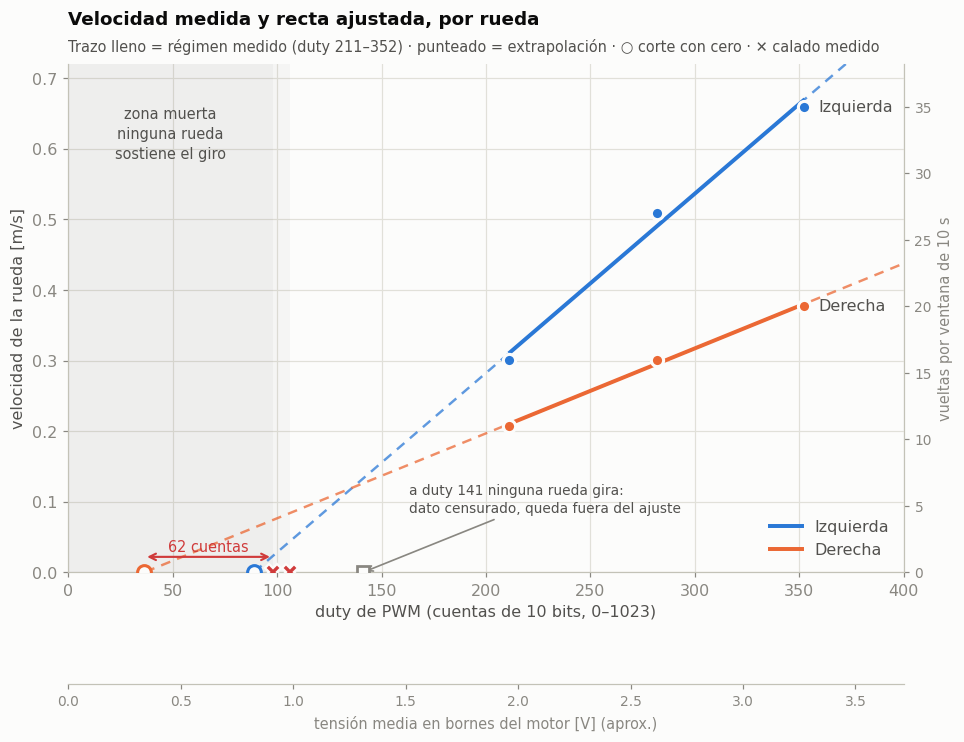

In [5]:
# --- FIGURA 1: velocidad medida vs duty, ajustes y zona muerta ------------
CALADO_IZQ, CALADO_DER = 106, 98        # duty de calado medido con la rampa K
D_MIN_MED, D_MAX_MED = 211, 352         # rango donde el modelo fue validado

fig, ax = plt.subplots(figsize=(9.8, 6.0))

# --- zonas muertas (infraestructura, no series: van en gris) ---
ax.axvspan(0, CALADO_DER, color="#0b0b0b", alpha=0.055, lw=0)
ax.axvspan(CALADO_DER, CALADO_IZQ, color="#0b0b0b", alpha=0.028, lw=0)
ax.text(CALADO_DER/2, 0.66, "zona muerta\nninguna rueda\nsostiene el giro",
        ha="center", va="top", fontsize=9.5, color=INK2, linespacing=1.4)

d = np.linspace(0, 400, 500)
for fit, col, lbl, calado, vueltas in (
        (fit_izq, C_IZQ, "Izquierda", CALADO_IZQ, VUELTAS_IZQ),
        (fit_der, C_DER, "Derecha",  CALADO_DER, VUELTAS_DER)):
    v = vueltas_a_ms(fit["k"] * (d - fit["piso"]))
    dentro = (d >= D_MIN_MED) & (d <= D_MAX_MED)
    ax.plot(d[dentro], v[dentro], color=col, lw=2.6, zorder=3, label=lbl)          # régimen validado
    fuera = (d > fit["piso"]) & ~dentro
    ax.plot(d[fuera], v[fuera], color=col, lw=1.6, ls=(0, (4, 3)), alpha=0.75, zorder=3)
    # puntos donde la rueda efectivamente gira
    activo = vueltas > 0
    ax.plot(DUTY_MEDIDO[activo], vueltas_a_ms(vueltas[activo]), "o", color=col,
            mec=SURFACE, mew=2, zorder=5)
    # corte con cero (extrapolación) y calado real (medición)
    ax.plot([fit["piso"]], [0], "o", mfc=SURFACE, mec=col, mew=2, ms=9, zorder=6)
    ax.plot([calado], [0], "X", color=C_CRIT, ms=11, mec=SURFACE, mew=1.5, zorder=7)
    # etiqueta directa junto al último punto medido (tinta, no color de serie)
    ax.annotate(lbl, (D_MAX_MED, vueltas_a_ms(vueltas[-1])), xytext=(10, 0),
                textcoords="offset points", va="center", color=INK2, fontsize=10.5)

# el punto censurado: a duty 141 ninguna de las dos ruedas gira
ax.plot([141], [0], "s", mfc=SURFACE, mec=MUTED, mew=1.8, ms=8, zorder=6)
ax.annotate("a duty 141 ninguna rueda gira:\ndato censurado, queda fuera del ajuste",
            (141, 0), xytext=(163, 0.085), textcoords="data", fontsize=9, color=INK2,
            linespacing=1.4, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.1))

# la brecha de la derecha: corte con cero vs calado real
ax.annotate("", xy=(CALADO_DER, 0.022), xytext=(fit_der["piso"], 0.022),
            arrowprops=dict(arrowstyle="<->", color=C_CRIT, lw=1.4))
ax.text(0.5*(CALADO_DER + fit_der["piso"]), 0.030,
        f"{CALADO_DER - fit_der['piso']:.0f} cuentas", ha="center", color=C_CRIT, fontsize=9.5)

ax.set_xlim(0, 400); ax.set_ylim(0, 0.72)
ax.set_xlabel("duty de PWM (cuentas de 10 bits, 0–1023)")
ax.set_ylabel("velocidad de la rueda [m/s]")
marco(ax, "Velocidad medida y recta ajustada, por rueda",
      "Trazo lleno = régimen medido (duty 211–352) · punteado = extrapolación · "
      "○ corte con cero · ✕ calado medido")
ax.legend(loc="lower right", labelcolor=INK2)

# ejes gemelos: la MISMA magnitud en otras unidades (no es un doble eje de dos medidas)
sec_x = ax.secondary_xaxis(-0.22, functions=(duty_a_volt, lambda v: v * PWM_MAX / V_BORNES_100))
sec_x.set_xlabel("tensión media en bornes del motor [V] (aprox.)", color=MUTED, fontsize=9.5)
sec_x.tick_params(colors=MUTED, labelsize=9)
sec_x.spines["bottom"].set_color(AXIS)
sec_y = ax.secondary_yaxis("right", functions=(ms_a_vueltas, vueltas_a_ms))
sec_y.set_ylabel("vueltas por ventana de 10 s", color=MUTED, fontsize=9.5)
sec_y.tick_params(colors=MUTED, labelsize=9)

guardar(fig, "fig1_rectas_calibracion.png")
plt.show()

La figura concentra el argumento de esta sección:

- Las dos rectas **tienen pendientes distintas** — no se trata de correr una respecto de la otra, hay que reescalarlas.
- El tramo **lleno** es el único donde el modelo fue validado (duty 211 a 352). Todo lo punteado es **extrapolación**, y es ahí donde el proyecto se equivocó dos veces.
- Los marcadores ○ (corte con cero de la recta) y ✕ (calado realmente medido) **no coinciden**: en la rueda derecha hay **62 cuentas** de diferencia. La recta ajustada describe bien el régimen medido y no dice nada sobre dónde se planta la rueda, porque cerca de velocidad cero la fricción crece más que lineal.

## 4. Dos calibraciones que fallaron

Antes de la calibración final hubo dos mapas cargados en el firmware que no funcionaron. Vale documentarlos porque cada uno enseña algo distinto — y porque los dos síntomas se explican con el modelo ya ajustado.

### 4.1 Primer intento — pisos estáticos y techo común

Se cargó `PWM_MIN` = umbral **estático** de cada rueda (256 / 128 en 10 bits) y un `PWM_TOP` **común** de 352. Al comandar 20 % la fórmula aplicaba:

| Rueda | `PWM_MIN` | Cuenta | Duty a `u` = 0,20 |
|---|---|---|---|
| Izquierda | 256 | `256 + 96 × 0,20` | **275** |
| Derecha | 128 | `128 + 224 × 0,20` | **172** |

La izquierda recibía 60 % más duty que la derecha... y encima es la que más velocidad da por cuenta. Dos errores encadenados:

1. **Los `v_min` cargados son los estáticos, no los cinéticos.** La fórmula supone velocidad **cero** en `PWM_MIN`, y eso es falso: es el duty al que la rueda *se despega desde parado*, y una rueda ya en movimiento a ese duty gira a una velocidad muy apreciable. Como el umbral estático de la izquierda es el doble, la fórmula la lanzaba a una velocidad de arranque mucho mayor.
2. **La fórmula iguala los extremos del *duty*, no los de la *velocidad*.** Con `u = 1` las dos ruedas reciben el mismo `PWM_TOP`, y no hay ninguna razón para que a ese duty corran igual. Compensar el piso arregla el arranque y no arregla la pendiente.

### 4.2 Segundo intento — el corte con cero como piso

Corregido lo anterior, se cargó `PWM_MIN` = **corte con cero del ajuste** (89 / 36) y `PWM_TOP` por rueda (238 / 352). En el modelo las dos velocidades quedan iguales. En el banco, la rueda derecha **se plantaba a comando chico**.

El motivo está en la Figura 1: el corte con cero es una extrapolación de una recta ajustada entre 211 y 352, y la rueda se cala mucho antes de llegar ahí. Con 36 cargado, la derecha quedaba **por debajo de su propio duty de calado** en toda la parte baja del rango.

> El síntoma no había aparecido en la prueba porque se probó justo a `u` = 0,2, que da duty 99 — un punto que quedó *en el borde* del calado y funcionó de casualidad.

Izquierda : se planta para todo u < 0.114
Derecha   : se planta para todo u < 0.196


figura guardada en figuras/fig2_mapas_fallidos.png


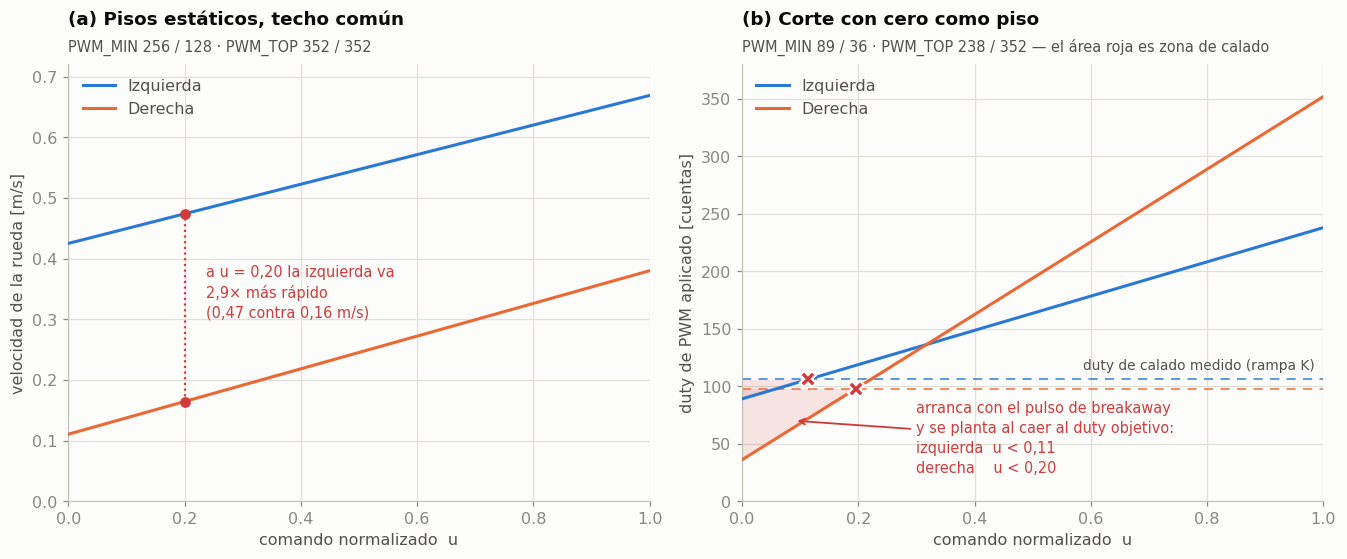

In [6]:
# --- FIGURA 2: los dos mapas que fallaron --------------------------------
def duty_de_u(u, pwm_min, pwm_top):
    return pwm_min + (pwm_top - pwm_min) * np.asarray(u, float)

def velocidad_de_u(u, pwm_min, pwm_top, fit):
    return vueltas_a_ms(fit["k"] * (duty_de_u(u, pwm_min, pwm_top) - fit["piso"]))

u = np.linspace(0, 1, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 5.2))

# ---- (a) mapa con umbrales estáticos y techo común ----
MAPA_A = {"izq": (256, 352), "der": (128, 352)}
for lado, col, lbl, fit in (("izq", C_IZQ, "Izquierda", fit_izq), ("der", C_DER, "Derecha", fit_der)):
    ax1.plot(u, velocidad_de_u(u, *MAPA_A[lado], fit), color=col, label=lbl, zorder=3)

v_a_izq = velocidad_de_u(0.2, *MAPA_A["izq"], fit_izq)
v_a_der = velocidad_de_u(0.2, *MAPA_A["der"], fit_der)
ax1.plot([0.2, 0.2], [v_a_der, v_a_izq], color=C_CRIT, lw=1.4, ls=":", zorder=4)
ax1.plot([0.2, 0.2], [v_a_der, v_a_izq], "o", color=C_CRIT, ms=6, zorder=5)
ax1.annotate(f"a u = 0,20 la izquierda va\n{coma(v_a_izq/v_a_der, 1)}× más rápido\n"
             f"({coma(v_a_izq)} contra {coma(v_a_der)} m/s)",
             (0.2, 0.5*(v_a_izq+v_a_der)), xytext=(14, -6), textcoords="offset points",
             fontsize=9.5, color=C_CRIT, linespacing=1.35)
ax1.set_xlabel("comando normalizado  u")
ax1.set_ylabel("velocidad de la rueda [m/s]")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 0.72)
marco(ax1, "(a) Pisos estáticos, techo común",
      "PWM_MIN 256 / 128 · PWM_TOP 352 / 352")
ax1.legend(loc="upper left", labelcolor=INK2)

# ---- (b) mapa con el corte con cero como piso ----
MAPA_B = {"izq": (89, 238), "der": (36, 352)}
for lado, col, lbl, fit, calado in (("izq", C_IZQ, "Izquierda", fit_izq, CALADO_IZQ),
                                    ("der", C_DER, "Derecha", fit_der, CALADO_DER)):
    dut = duty_de_u(u, *MAPA_B[lado])
    ax2.plot(u, dut, color=col, label=lbl, zorder=3)
    ax2.axhline(calado, color=col, lw=1.2, ls=(0, (5, 4)), alpha=0.8, zorder=2)
    u_cal = (calado - MAPA_B[lado][0]) / (MAPA_B[lado][1] - MAPA_B[lado][0])
    ax2.fill_between(u, dut, calado, where=(dut < calado), color=C_CRIT, alpha=0.13, lw=0, zorder=1)
    ax2.plot([u_cal], [calado], "X", color=C_CRIT, ms=11, mec=SURFACE, mew=1.5, zorder=6)
    print(f"{lbl:10s}: se planta para todo u < {u_cal:.3f}")

ax2.annotate("arranca con el pulso de breakaway\ny se planta al caer al duty objetivo:\n"
             "izquierda  u < 0,11\nderecha    u < 0,20",
             (0.09, 70), xytext=(0.30, 25), textcoords="data", fontsize=9.5,
             color=C_CRIT, linespacing=1.4,
             arrowprops=dict(arrowstyle="->", color=C_CRIT, lw=1.2))
ax2.text(0.985, CALADO_IZQ + 6, "duty de calado medido (rampa K)", ha="right",
         va="bottom", fontsize=9, color=INK2)
ax2.set_xlabel("comando normalizado  u")
ax2.set_ylabel("duty de PWM aplicado [cuentas]")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 380)
marco(ax2, "(b) Corte con cero como piso",
      "PWM_MIN 89 / 36 · PWM_TOP 238 / 352 — el área roja es zona de calado")
ax2.legend(loc="upper left", labelcolor=INK2)

fig.tight_layout()
guardar(fig, "fig2_mapas_fallidos.png")
plt.show()

El panel (b) trae además un detalle que no se había registrado: con ese mapa **también la izquierda** quedaba por debajo de su calado, aunque en una franja mucho más angosta (`u` < 0,11 contra `u` < 0,20 de la derecha). El síntoma se llevó toda la atención en la rueda derecha porque ahí la brecha era de 62 cuentas contra 17.

*(El valor documentado en `HARDWARE.md` es `u` < 0,22; la diferencia con el 0,20 que sale acá es sólo qué extremo del calado medido se toma — las marcas de la rampa `K` en la rueda derecha fueron 90, 82, 92 y 98, y el calado real está por encima del valor marcado por el tiempo de reacción.)*

## 5. La calibración final: dos ruedas, dos rectas, una sola velocidad

El criterio correcto sale de escribir lo que se quiere y despejar. Se quiere que **las dos ruedas recorran la misma recta de velocidad** en función del comando:

$$v(u) \;=\; v_{lo} + (v_{hi} - v_{lo})\cdot u \qquad \text{igual para ambas ruedas}$$

Y de la caracterización de cada motor sabemos que $v_i = k_i\,(d_i - p_i)$, o sea $d_i = p_i + v_i/k_i$. Sustituyendo:

$$d_i(u) \;=\; \underbrace{\Big(p_i + \frac{v_{lo}}{k_i}\Big)}_{\text{PWM\_MIN}_i} \;+\; \underbrace{\frac{v_{hi}-v_{lo}}{k_i}}_{\text{pendiente}}\cdot u$$

Que es **exactamente la forma que el firmware ya implementa**. No hay que cambiar código: hay que elegir bien $v_{lo}$ y $v_{hi}$ y despejar los cuatro números.

**Cómo se eligen los dos extremos — manda siempre la rueda más limitada:**

- $v_{hi}$: la rueda **más lenta** (la derecha) se queda en su tope de 352 y define la velocidad máxima común; la izquierda baja su techo hasta igualarla.
- $v_{lo}$: la **mínima velocidad que las dos ruedas pueden sostener**, medida con la rampa `K`. La izquierda sostiene 2,6 vueltas/10 s (0,049 m/s) y la derecha 4,5 (0,084 m/s) → **manda la derecha**. Además hay que dejar margen por encima del calado, porque el calado se movió entre repeticiones.

In [7]:
# --- Cálculo de los cuatro números ---------------------------------------
V_MIN_SOSTENIBLE = {"izq": vueltas_a_ms(2.6), "der": vueltas_a_ms(4.5)}   # medido con K
PWM_TOP_DER = 352                                                        # la rueda lenta se queda en su tope

v_hi = vueltas_a_ms(fit_der["k"] * (PWM_TOP_DER - fit_der["piso"]))      # velocidad máxima común
v_lo = max(V_MIN_SOSTENIBLE.values())                                    # la derecha manda

def duty_para(v, fit):
    return fit["piso"] + ms_a_vueltas(v) / fit["k"]

# Valores finalmente cargados en el firmware (con margen sobre el calado)
CARGADO = {"PWM_MIN": (125, 112), "PWM_TOP": (238, 352), "PWM_BREAKAWAY": (290, 220)}

calc = pd.DataFrame({
    "Izquierda": [duty_para(v_lo, fit_izq), duty_para(v_hi, fit_izq), CALADO_IZQ,
                  CARGADO["PWM_MIN"][0], CARGADO["PWM_TOP"][0],
                  CARGADO["PWM_MIN"][0] - CALADO_IZQ],
    "Derecha":   [duty_para(v_lo, fit_der), duty_para(v_hi, fit_der), CALADO_DER,
                  CARGADO["PWM_MIN"][1], CARGADO["PWM_TOP"][1],
                  CARGADO["PWM_MIN"][1] - CALADO_DER],
}, index=["duty calculado para v_lo", "duty calculado para v_hi", "duty de calado medido",
          "PWM_MIN cargado", "PWM_TOP cargado", "margen sobre el calado [cuentas]"]).round(1)

print(f"v_hi (velocidad máxima común) : {v_hi:.4f} m/s   ({ms_a_vueltas(v_hi):.1f} vueltas/10 s)")
print(f"v_lo (mínima sostenible)      : {v_lo:.4f} m/s   ({ms_a_vueltas(v_lo):.1f} vueltas/10 s)")
print()
calc

v_hi (velocidad máxima común) : 0.3800 m/s   (20.2 vueltas/10 s)
v_lo (mínima sostenible)      : 0.0848 m/s   (4.5 vueltas/10 s)



,Izquierda,Derecha
duty calculado para v_lo,122.2,106.8
duty calculado para v_hi,238.3,352.0
duty de calado medido,106.0,98.0
PWM_MIN cargado,125.0,112.0
PWM_TOP cargado,238.0,352.0
margen sobre el calado [cuentas],19.0,14.0


Los `PWM_MIN` calculados a partir de $v_{lo}$ (≈122 y ≈106) quedan **muy cerca del calado medido** (106 y 98): 16 y 8 cuentas de margen. Se cargaron algo más arriba —**125 y 112**— para tener 19 y 14 cuentas de colchón, porque el calado varió entre repeticiones y una rueda plantada a comando bajo es una falla dura.

Ese redondeo tiene un efecto secundario que conviene explicitar: al subir los dos pisos, la velocidad mínima real sube de 0,084 a **0,091 m/s**. Lo importante es que **los dos pisos cargados corresponden a la misma velocidad** — que es toda la condición que hay que cumplir.

In [8]:
# --- Verificación del mapa cargado ---------------------------------------
MAPA_FINAL = {"izq": (CARGADO["PWM_MIN"][0], CARGADO["PWM_TOP"][0]),
              "der": (CARGADO["PWM_MIN"][1], CARGADO["PWM_TOP"][1])}

u_chk = np.array([0.0, 0.1, 0.2, 0.4, 0.6, 1.0])
v_izq = velocidad_de_u(u_chk, *MAPA_FINAL["izq"], fit_izq)
v_der = velocidad_de_u(u_chk, *MAPA_FINAL["der"], fit_der)

# Extremos reales del rango, promediando las dos ruedas (difieren < 0,5 %)
v_lo_final = 0.5 * (v_izq[0] + v_der[0])
v_hi_final = 0.5 * (v_izq[-1] + v_der[-1])

verif = pd.DataFrame({
    "u": u_chk,
    "duty izq": duty_de_u(u_chk, *MAPA_FINAL["izq"]).round(0).astype(int),
    "duty der": duty_de_u(u_chk, *MAPA_FINAL["der"]).round(0).astype(int),
    "V media izq": duty_a_volt(duty_de_u(u_chk, *MAPA_FINAL["izq"])).round(2),
    "V media der": duty_a_volt(duty_de_u(u_chk, *MAPA_FINAL["der"])).round(2),
    "m/s izq": v_izq.round(4),
    "m/s der": v_der.round(4),
    "error [%]": (100 * (v_izq - v_der) / v_der).round(2),
})

u_fino = np.linspace(0, 1, 501)
err = 100 * (velocidad_de_u(u_fino, *MAPA_FINAL["izq"], fit_izq)
             - velocidad_de_u(u_fino, *MAPA_FINAL["der"], fit_der)) \
      / velocidad_de_u(u_fino, *MAPA_FINAL["der"], fit_der)
print(f"Discrepancia máxima entre ruedas en todo el rango: {np.abs(err).max():.2f} %")
print(f"Cuentas útiles por rueda: izquierda {MAPA_FINAL['izq'][1]-MAPA_FINAL['izq'][0]}, "
      f"derecha {MAPA_FINAL['der'][1]-MAPA_FINAL['der'][0]}  "
      f"(en 8 bits habrían sido {(MAPA_FINAL['izq'][1]-MAPA_FINAL['izq'][0])//4} y "
      f"{(MAPA_FINAL['der'][1]-MAPA_FINAL['der'][0])//4})")
verif

Discrepancia máxima entre ruedas en todo el rango: 0.98 %
Cuentas útiles por rueda: izquierda 113, derecha 240  (en 8 bits habrían sido 28 y 60)


,u,duty izq,duty der,V media izq,V media der,m/s izq,m/s der,error [%]
0,0.0,125,112,1.16,1.04,0.0920,0.0911,0.98
1,0.1,136,136,1.27,1.26,0.1207,0.1200,0.60
2,0.2,148,160,1.37,1.49,0.1494,0.1489,0.37
3,0.4,170,208,1.58,1.93,0.2069,0.2067,0.10
4,0.6,193,256,1.79,2.38,0.2643,0.2644,-0.05
5,1.0,238,352,2.21,3.27,0.3791,0.3800,-0.22


figura guardada en figuras/fig3_calibracion_final.png


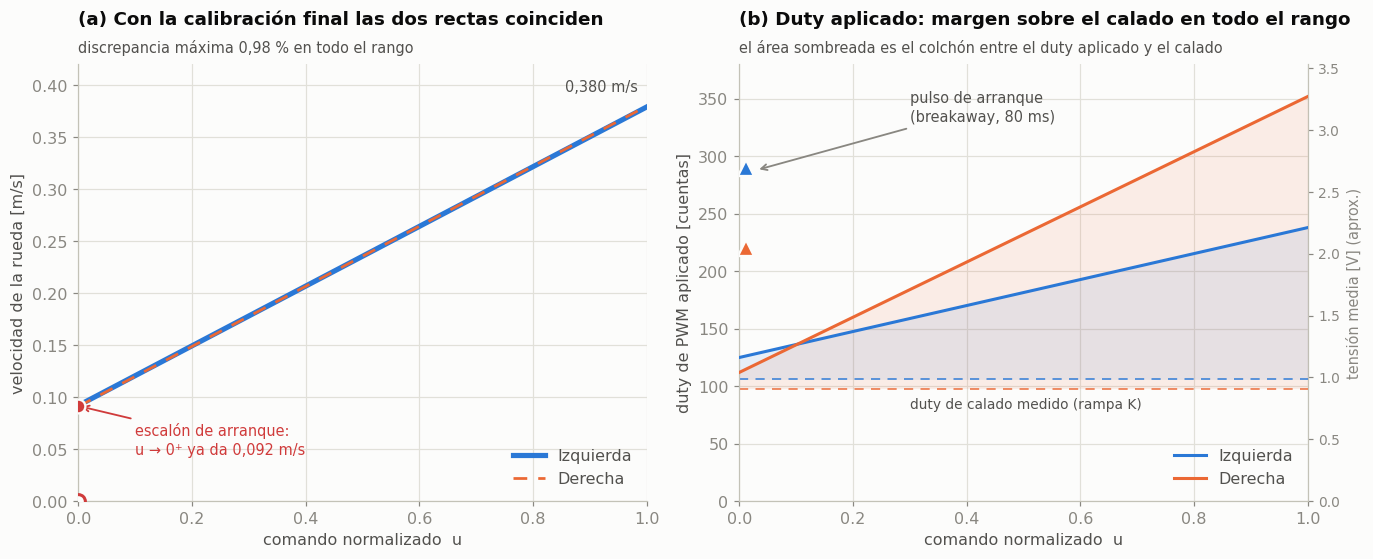

In [9]:
# --- FIGURA 3: el mapa calibrado -----------------------------------------
u = np.linspace(0, 1, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 5.2))

# ---- (a) velocidad vs comando: las dos rectas superpuestas ----
ax1.plot(u, velocidad_de_u(u, *MAPA_FINAL["izq"], fit_izq), color=C_IZQ, lw=3.4,
         label="Izquierda", zorder=3)
ax1.plot(u, velocidad_de_u(u, *MAPA_FINAL["der"], fit_der), color=C_DER, lw=1.8,
         ls=(0, (5, 4)), label="Derecha", zorder=4)
ax1.plot([0], [velocidad_de_u(0, *MAPA_FINAL["der"], fit_der)], "o", color=C_CRIT,
         ms=9, mec=SURFACE, mew=1.5, zorder=6)
ax1.plot([0], [0], "o", mfc=SURFACE, mec=C_CRIT, mew=2, ms=9, zorder=6)
ax1.annotate(f"escalón de arranque:\nu → 0⁺ ya da {coma(v_lo_final, 3)} m/s",
             (0, v_lo_final), xytext=(0.10, 0.045), textcoords="data",
             fontsize=9.5, color=C_CRIT, linespacing=1.35,
             arrowprops=dict(arrowstyle="->", color=C_CRIT, lw=1.2))
ax1.annotate(f"{coma(v_hi_final, 3)} m/s", (1, v_hi_final), xytext=(-6, 10),
             textcoords="offset points", ha="right", fontsize=9.5, color=INK2)
ax1.set_xlabel("comando normalizado  u")
ax1.set_ylabel("velocidad de la rueda [m/s]")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 0.42)
marco(ax1, "(a) Con la calibración final las dos rectas coinciden",
      f"discrepancia máxima {coma(np.abs(err).max())} % en todo el rango")
ax1.legend(loc="lower right", labelcolor=INK2)

# ---- (b) duty aplicado, con calado y pulso de arranque ----
for lado, col, lbl, calado, brk in (("izq", C_IZQ, "Izquierda", CALADO_IZQ, 290),
                                    ("der", C_DER, "Derecha", CALADO_DER, 220)):
    dut = duty_de_u(u, *MAPA_FINAL[lado])
    ax2.plot(u, dut, color=col, label=lbl, zorder=3)
    ax2.axhline(calado, color=col, lw=1.2, ls=(0, (5, 4)), alpha=0.8, zorder=2)
    ax2.fill_between(u, calado, dut, color=col, alpha=0.10, lw=0, zorder=1)
    ax2.plot([0.012], [brk], "^", color=col, ms=10, mec=SURFACE, mew=1.5, zorder=5)

ax2.text(0.30, CALADO_DER - 8, "duty de calado medido (rampa K)", ha="left", va="top",
         fontsize=9, color=INK2)
ax2.annotate("pulso de arranque\n(breakaway, 80 ms)", (0.03, 288), xytext=(0.30, 330),
             textcoords="data", fontsize=9.5, color=INK2, linespacing=1.35,
             arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax2.set_xlabel("comando normalizado  u")
ax2.set_ylabel("duty de PWM aplicado [cuentas]")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 380)
marco(ax2, "(b) Duty aplicado: margen sobre el calado en todo el rango",
      "el área sombreada es el colchón entre el duty aplicado y el calado")
ax2.legend(loc="lower right", labelcolor=INK2)

sec = ax2.secondary_yaxis("right", functions=(duty_a_volt, lambda v: v*PWM_MAX/V_BORNES_100))
sec.set_ylabel("tensión media [V] (aprox.)", color=MUTED, fontsize=9.5)
sec.tick_params(colors=MUTED, labelsize=9)

fig.tight_layout()
guardar(fig, "fig3_calibracion_final.png")
plt.show()

> **Alcance de esta verificación.** Los valores de la tabla y de la Figura 3 son la **predicción del modelo** con los parámetros cargados, no una segunda medición independiente. Lo que sí se verificó en banco fue **cualitativo**: ruedas parejas a 10, 20, 40, 60 y 100 % de comando, sin fallas de arranque ni calado. El 10 % es el punto que importa, porque con el mapa anterior ahí la rueda derecha se plantaba.
>
> Queda pendiente la verificación **cuantitativa**: repetir las ventanas `V` pero a **comando calibrado** en vez de duty crudo, y contar vueltas. Es media hora de banco y cierra el lazo de la medición.

## 6. Rango útil y presupuesto del lazo de visión

La calibración no sólo empareja las ruedas: define el **rango de velocidades que el robot puede usar**, y ese rango tiene que ser compatible con la percepción. Con inferencia YOLOv8n a ~5 FPS, lo que importa es **cuánto avanza el robot entre un frame y el siguiente**: ese es el "salto a ciegas" del lazo de control.

figura guardada en figuras/fig4_rango_util.png


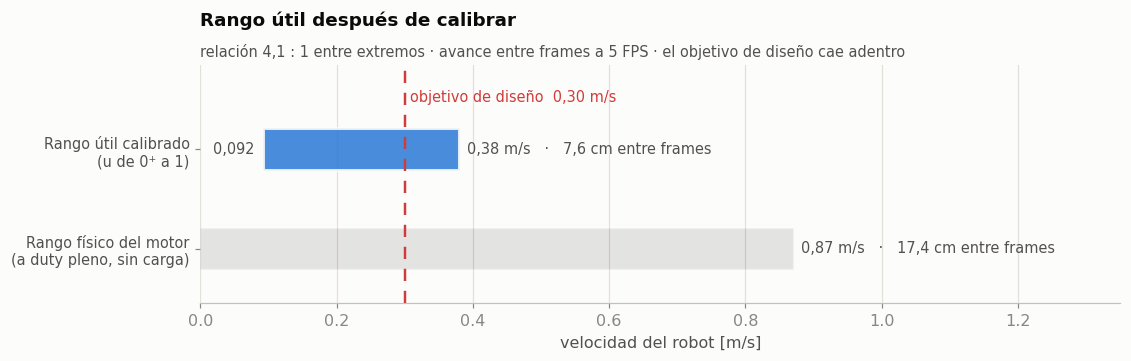

Rango útil : 0.092 – 0.380 m/s   (4.1 : 1)
Avance por frame a 5 FPS : 1.8 – 7.6 cm


In [10]:
# --- FIGURA 4: rango útil contra el presupuesto de visión ----------------
V_SIN_CARGA = 0.87       # estimación a duty pleno, ruedas al aire (HARDWARE.md §0.3)
V_OBJETIVO  = 0.30       # objetivo de diseño (PLAN.md §7)

fig, ax = plt.subplots(figsize=(10.4, 3.4))

barras = [
    ("Rango físico del motor\n(a duty pleno, sin carga)", 0.0, V_SIN_CARGA, "#0b0b0b", 0.10),
    ("Rango útil calibrado\n(u de 0⁺ a 1)", v_lo_final, v_hi_final, C_IZQ, 0.85),
]
for i, (etq, x0, x1, col, alpha) in enumerate(barras):
    ax.barh(i, x1 - x0, left=x0, height=0.42, color=col, alpha=alpha,
            edgecolor=SURFACE, linewidth=2, zorder=3)
    ax.text(x1 + 0.012, i, f"{coma(x1)} m/s   ·   {coma(x1*100/FPS_VISION, 1)} cm entre frames",
            va="center", fontsize=9.5, color=INK2)
    if x0 > 0:
        ax.text(x0 - 0.012, i, coma(x0, 3), va="center", ha="right", fontsize=9.5, color=INK2)

ax.axvline(V_OBJETIVO, color=C_CRIT, lw=1.6, ls=(0, (5, 4)), zorder=4)
ax.text(V_OBJETIVO + 0.008, 1.45, f"objetivo de diseño  {coma(V_OBJETIVO)} m/s",
        fontsize=9.5, color=C_CRIT, va="bottom")

ax.set_yticks(range(len(barras)))
ax.set_yticklabels([b[0] for b in barras], fontsize=9.5, color=INK2)
ax.set_xlim(0, 1.35); ax.set_ylim(-0.55, 1.85)
ax.set_xlabel("velocidad del robot [m/s]")
marco(ax, "Rango útil después de calibrar",
      f"relación {coma(v_hi_final/v_lo_final, 1)} : 1 entre extremos · "
      f"avance entre frames a {FPS_VISION:.0f} FPS · el objetivo de diseño cae adentro")
ax.grid(False, axis="y")
ax.spines["left"].set_visible(False)

fig.tight_layout()
guardar(fig, "fig4_rango_util.png")
plt.show()

print(f"Rango útil : {v_lo_final:.3f} – {v_hi_final:.3f} m/s   ({v_hi_final/v_lo_final:.1f} : 1)")
print(f"Avance por frame a {FPS_VISION:.0f} FPS : "
      f"{v_lo_final*100/FPS_VISION:.1f} – {v_hi_final*100/FPS_VISION:.1f} cm")

## 7. Consecuencias para la ley de control

La calibración deja tres restricciones que la ley de control del Pi tiene que respetar:

1. 🔴 **No hay arranque suave desde cero.** Cualquier `u > 0` produce **al menos 0,091 m/s**. Es un escalón, no una rampa. Para parar, el Pi tiene que mandar **exactamente** `M,0,0`; un valor chico no hace que el robot vaya despacio, lo hace ir a 0,091 m/s. Refuerza la conveniencia de una **zona muerta alrededor del centro** en la ley de control.
2. **La resolución quedó pareja y suficiente:** 113 cuentas útiles en la izquierda y 240 en la derecha. En escala de 8 bits habrían sido 28 y 60 — de ahí que se haya pasado el PWM a 10 bits antes de calibrar.
3. **La calibración vale sólo para las condiciones en que se midió** (ruedas al aire, batería cargada). Si la desviación cambia con la batería descargándose, con el tipo de piso o con peso encima, no hay constante que la siga y el arreglo son los **encoders**. Antes no: un PID sobre una planta descompensada arranca peor que sobre una calibrada.

**Dónde duele realmente la asimetría.** Vale acotar el problema: en el estado `APROXIMAR` casi no importa, porque la cámara cierra el lazo de rumbo frame a frame y una trayectoria curvada se corrige sola. Duele en los estados **sin realimentación visual**: `BUSCAR` rotando a ciegas y la fase final de `HUIR`.

---

## 8. Lección metodológica

Tres estimaciones de este proyecto cayeron por medición, y **las tres por el mismo motivo**: extrapolar un modelo fuera del rango donde se lo validó.

| Estimación | Lo que se predijo | Lo que se midió | Dónde estaba la extrapolación |
|---|---|---|---|
| Caída de tensión del L298 | 1,4 V | **2,5 V** | tabla del datasheet tomada a otra corriente y temperatura |
| Simetría de los motores | iguales, distinta fricción | **2,11× en la pendiente** | se supuso a partir de la chapa, sin medir |
| Piso de la recta de control | 89 / 36 (corte con cero) | **~106 / ~98** (calado real) | recta ajustada entre duty 211 y 352, usada en duty ≈ 0 |

El tercero es el más instructivo porque el modelo era **correcto**: R² > 0,99 en el régimen medido. Lo que falló no fue el ajuste sino su **dominio de validez**. Cerca de velocidad cero la fricción crece más que lineal, así que la recta describe muy bien lo que se midió y **no dice nada** sobre dónde se planta la rueda. El único remedio fue medir ahí: la rampa `K`.

### Qué queda pendiente

- [ ] **Verificación cuantitativa** del mapa calibrado: ventanas `V` a comando calibrado, contando vueltas (hoy la verificación es cualitativa + predicción del modelo).
- [ ] **Prueba de recta en piso**: `M,30,0` sostenido, medir el desvío en 2 m. Es lo que decide si hacen falta encoders.
- [ ] Ajustar `BREAKAWAY_MS` (hoy 80 ms, elegido sin medir) si el tirón de arranque molesta.
- [ ] Mirar la **etiqueta de cada motor** para confirmar la hipótesis de reducciones distintas.

In [11]:
# --- Resumen: lo que quedó cargado en el firmware ------------------------
resumen = pd.DataFrame({
    "Constante": ["PWM_RES_BITS", "PWM_FREQ_HZ", "PWM_MIN_*", "PWM_TOP_*",
                  "PWM_BREAKAWAY_*", "BREAKAWAY_MS"],
    "Izquierda": ["10 bits (0–1023)", "1000 Hz", CARGADO["PWM_MIN"][0], CARGADO["PWM_TOP"][0],
                  CARGADO["PWM_BREAKAWAY"][0], "80 ms"],
    "Derecha":   ["10 bits (0–1023)", "1000 Hz", CARGADO["PWM_MIN"][1], CARGADO["PWM_TOP"][1],
                  CARGADO["PWM_BREAKAWAY"][1], "80 ms"],
    "Cómo se obtuvo": ["decisión de diseño (granularidad)", "validado en bring-up",
                       "v_lo común + margen sobre el calado medido con K",
                       "la rueda lenta se queda en su tope; la rápida se baja para igualar",
                       "umbral estático acotado por las ventanas V",
                       "compromiso sin medir: plantarse vs tirón visible"],
})
print("Rango útil del robot: "
      f"{v_lo_final:.3f} – {v_hi_final:.3f} m/s   ({v_hi_final/v_lo_final:.1f} : 1)\n")
resumen

Rango útil del robot: 0.092 – 0.380 m/s   (4.1 : 1)



,Constante,Izquierda,Derecha,Cómo se obtuvo
0,PWM_RES_BITS,10 bits (0–1023),10 bits (0–1023),decisión de diseño (granularidad)
1,PWM_FREQ_HZ,1000 Hz,1000 Hz,validado en bring-up
2,PWM_MIN_*,125,112,v_lo común + margen sobre el calado medido con K
3,PWM_TOP_*,238,352,la rueda lenta se queda en su tope; la rápida ...
4,PWM_BREAKAWAY_*,290,220,umbral estático acotado por las ventanas V
5,BREAKAWAY_MS,80 ms,80 ms,compromiso sin medir: plantarse vs tirón visible
